#  Accessing and processing data from APIs (REST, SOAP) 
# Acessing REST API using Python
Get Request

In [ ]:
import requests
from pprint import pprint
url = "https://jsonplaceholder.typicode.com/posts/1"

response = requests.get(url)
print(response)
print(type(response))

<Response [200]>
<class 'requests.models.Response'>


In [ ]:
if response.status_code == 200:
    data = response.json()
    pprint(data)
else:
    print("Error: ", response.status_code)

post request


In [ ]:
url = "https://jsonplaceholder.typicode.com/posts"
payload = {"title": "Test", "body": "Hello API", "userId": 11}
response = requests.post(url,json=payload)
pprint(response.json())

{'args': {}, 'data': '{"name": "Ayush", "age": 19}', 'files': {}, 'form': {}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate', 'Content-Length': '28', 'Content-Type': 'application/json', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.5', 'X-Amzn-Trace-Id': 'Root=1-696f9962-7dd816eb01a39665399c5f9c'}, 'json': {'age': 19, 'name': 'Ayush'}, 'origin': '27.34.68.181', 'url': 'https://httpbin.org/post'}


In [ ]:
import requests

url = "https://httpbin.org/post"

payload = {
    "name": "Ayush",
    "age": 19
}

response = requests.post(url, json=payload)

print(response.json())


# acessing soap api

In [13]:
from zeep import Client

#WSDL URL
wsdl = "http://www.dneonline.com/calculator.asmx?WSDL"
client = Client(wsdl = wsdl)

result = client.service.Add(10,20)
print(result)

30


In [15]:
import requests

# SOAP endpoint
url = "http://www.dneonline.com/calculator.asmx"

# SOAP envelope (XML) for adding 5 + 10
soap_body = """<?xml version="1.0" encoding="utf-8"?>
<soap:Envelope xmlns:soap="http://schemas.xmlsoap.org/soap/envelope/">
  <soap:Body>
    <Add xmlns="http://tempuri.org/">
      <intA>5</intA>
      <intB>10</intB>
    </Add>
  </soap:Body>
</soap:Envelope>"""

# HTTP headers
headers = {
    "Content-Type": "text/xml; charset=utf-8",
    "SOAPAction": "http://tempuri.org/Add"
}

# Make the POST request
response = requests.post(url, data=soap_body, headers=headers)

# Print raw XML response
print(response.text)


ConnectionError: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))

# Weather API


In [ ]:

import requests
import os
from dotenv import load_dotenv
load_dotenv()


def get_weather(city_name, api_key):
    # API endpoint
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city_name}&appid={api_key}&units=metric"

    # Make request
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        temp = data['main']['temp']
        weather_desc = data['weather'][0]['description']
        print(f"Weather in {city_name}: {temp}°C, {weather_desc}")
    else:
        print(f"Error: Could not get data for {city_name}. Status code {response.status_code}")

# Example usage
api_key = os.getenv("API_KEY")
city = "New York"
get_weather(city, api_key)


Weather in New York: -8.69°C, clear sky


In [2]:
import requests

city = "Kathmandu"
res = requests.get(f"https://wttr.in/{city}?format=3") 
print(res.text)


Kathmandu: ☀️   +15°C



Intercept (b0): -11.937499999999986
Coefficient (b1): [3.34375]


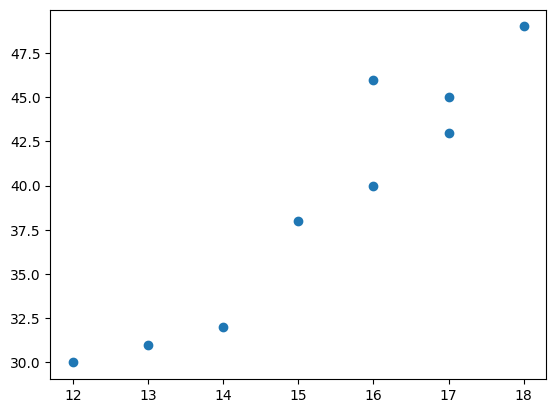

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Provide Data (example: simple linear regression)
# Input X must be a 2D array, y can be 1D
x = np.array([17,16,14,13,18,16,15,17,12]).reshape((-1, 1))
y = np.array([43,46,32,31,49,40,38,45,30])

# 2. Create and Fit the model
model = LinearRegression().fit(x, y)

# 3. Get results (coefficients)
intercept = model.intercept_
coefficients = model.coef_

print(f"Intercept (b0): {intercept}")
print(f"Coefficient (b1): {coefficients}")
# For multiple linear regression, coefficients will be an array of values
plt.scatter(x,y)
plt.show()



In [6]:
x = np.array([17,16,14,13,18,16,15,17,12])
y = np.array([43,46,32,31,49,40,38,45,30])
# Method: Covariance / Variance
b_yx = np.cov(x, y, ddof=0)[0, 1] / np.var(x)

print(f"Regression Coefficient (b_yx): {b_yx}")

Regression Coefficient (b_yx): 3.3437500000000004
